✅ Step 1: Load and Correct Column Names First

In [19]:
import pandas as pd

# Load the CSV (skip first 2 metadata rows)
df = pd.read_csv("data/AAPL_stock.csv", skiprows=2)

# Show the first few rows
print(df.head())


Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


KeyError: 'Date'

✅ Step 1: Visualize the Stock Price Trend


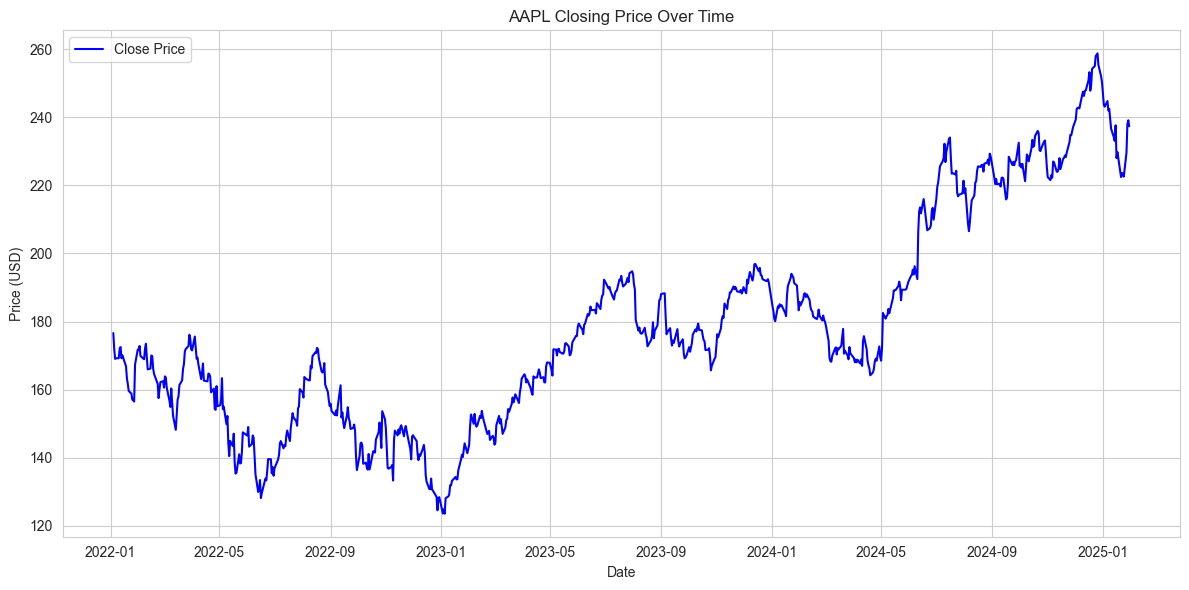

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"], label="Close Price", color="blue")
plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


✅ Step 2: Prepare Data for Prediction


In [12]:
# Shift closing prices by 1 day to use as a feature
df["Prev_Close"] = df["Close"].shift(1)
df = df.dropna()  # Drop the first row which has no Prev_Close


✅ Step 3: Train a Simple ML Model


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Features and target
X = df[["Prev_Close"]]
y = df["Close"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")


Mean Squared Error: 10.3343


✅ Step 4: Visualize Predictions


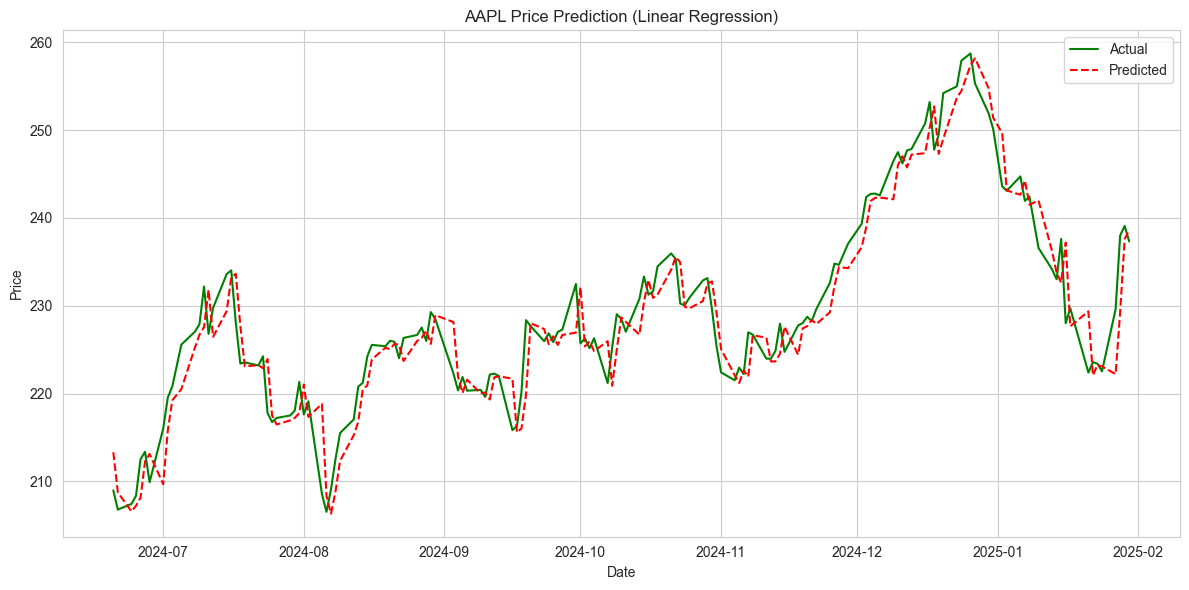

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(df["Date"].iloc[-len(y_test):], y_test.values, label="Actual", color="green")
plt.plot(df["Date"].iloc[-len(y_test):], y_pred, label="Predicted", color="red", linestyle="--")
plt.title("AAPL Price Prediction (Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
